# 02 · Predictor Strategies

Implements and compares five multicollinearity-handling strategies that feed into the SARIMAX models (notebook 03).

| # | Strategy | Core idea |
|---|----------|-----------|
| 0 | **OLS-All (Unregularised)** | Retain all features, no regularisation — shows the multicollinearity problem directly |
| 1 | **Correlation Filtering** | Remove highly correlated predictors (|r| > 0.80) |
| 2 | **PCA** | Replace collinear features with orthogonal components |
| 3 | **Ridge (L2)** | Retain all features; shrink coefficients with λ tuned by CV |
| 4 | **Lasso (L1)** | Regularise + implicit feature selection; α tuned by CV (optimal l1_ratio=1.0) |

**Strategy 0 is the unmitigated baseline.** Without any multicollinearity handling, OLS on all 18 features produces inflated, unstable, sign-inconsistent coefficients due to extreme VIF values (GDP VIF≈2387, population VIF≈1983). Strategies 1–4 each address this problem differently; comparing them against Strategy 0 makes the improvement concrete rather than assumed.

**Outputs saved to `data/`:**
- `strategy_filtered_{train,val,test}.csv`
- `strategy_pca_{train,val,test}.csv` + `strategy_pca_components.csv`
- `strategy_ridge_params.json`
- `strategy_elasticnet_{train,val,test}.csv` + `strategy_elasticnet_params.json`
- `strategy_ols_all_params.json`
- `predictor_strategies_summary.csv`

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## Load data and define feature groups

In [2]:
train = pd.read_csv('data/train.csv', parse_dates=['date'])
val   = pd.read_csv('data/val.csv',   parse_dates=['date'])
test  = pd.read_csv('data/test.csv',  parse_dates=['date'])

print(f'Train: {train.shape} | Val: {val.shape} | Test: {test.shape}')
print(f'Train period: {train.date.min().date()} → {train.date.max().date()}')
print(f'Test  period: {test.date.min().date()}  → {test.date.max().date()}')
print()

TARGET = 'demand_MW'

# Climate / physical weather features
CLIMATE = ['temp_c', 'wind_ms', 'precip_mm', 'sunshine_h',
           'global_rad', 'pressure_hpa', 'humidity_pct', 'cloudiness', 'nao']

# Structural / economic / renewable features
STRUCTURAL = ['price_eur_kwh', 'gdp_mln_eur', 'population',
              'wind_energy_gwh', 'solar_energy_gwh']

# Calendar features – always retained unchanged
CALENDAR = ['day_of_week', 'month', 'is_weekend', 'is_holiday']

CONTINUOUS = CLIMATE + STRUCTURAL          # 14 continuous predictors
ALL_FEATURES = CONTINUOUS + CALENDAR       # 18 total predictors

print(f'Continuous features : {len(CONTINUOUS)}')
print(f'Calendar features   : {len(CALENDAR)}')
print(f'Total features      : {len(ALL_FEATURES)}')
print()
print('Continuous:', CONTINUOUS)
print('Calendar  :', CALENDAR)

Train: (4281, 20) | Val: (917, 20) | Test: (919, 20)
Train period: 2009-01-01 → 2020-09-20
Test  period: 2023-03-27  → 2025-09-30

Continuous features : 14
Calendar features   : 4
Total features      : 18

Continuous: ['temp_c', 'wind_ms', 'precip_mm', 'sunshine_h', 'global_rad', 'pressure_hpa', 'humidity_pct', 'cloudiness', 'nao', 'price_eur_kwh', 'gdp_mln_eur', 'population', 'wind_energy_gwh', 'solar_energy_gwh']
Calendar  : ['day_of_week', 'month', 'is_weekend', 'is_holiday']


In [3]:
# ── Annual Fourier terms (k=2, period=365.25) ─────────────────────────────
# Smooth sinusoidal encoding of the annual demand cycle. The integer 'month'
# feature implies a linear ramp Jan→Dec with a discontinuous jump back to Jan;
# Fourier terms are smooth, periodic, and orthogonal — zero multicollinearity
# added. k=1 captures the main winter/summer swing; k=2 picks up the
# shoulder-season asymmetry. Added uniformly to all strategies so the
# comparison remains fair.

FOURIER_COLS = ['sin1_ann', 'cos1_ann', 'sin2_ann', 'cos2_ann']

def add_fourier(df: pd.DataFrame) -> pd.DataFrame:
    doy = df['date'].dt.dayofyear
    df = df.copy()
    df['sin1_ann'] = np.sin(2 * np.pi * doy / 365.25)
    df['cos1_ann'] = np.cos(2 * np.pi * doy / 365.25)
    df['sin2_ann'] = np.sin(4 * np.pi * doy / 365.25)
    df['cos2_ann'] = np.cos(4 * np.pi * doy / 365.25)
    return df

train = add_fourier(train)
val   = add_fourier(val)
test  = add_fourier(test)

# Extend CALENDAR and ALL_FEATURES — all downstream cells use these lists
CALENDAR     = CALENDAR + FOURIER_COLS
ALL_FEATURES = CONTINUOUS + CALENDAR

print(f'Fourier terms added : {FOURIER_COLS}')
print(f'CALENDAR ({len(CALENDAR)})     : {CALENDAR}')
print(f'Total features      : {len(ALL_FEATURES)}  ({len(CONTINUOUS)} continuous + {len(CALENDAR)} calendar+Fourier)')

Fourier terms added : ['sin1_ann', 'cos1_ann', 'sin2_ann', 'cos2_ann']
CALENDAR (8)     : ['day_of_week', 'month', 'is_weekend', 'is_holiday', 'sin1_ann', 'cos1_ann', 'sin2_ann', 'cos2_ann']
Total features      : 22  (14 continuous + 8 calendar+Fourier)


In [4]:
# ── Scale continuous features ──────────────────────────────────────────────
# Scaler fitted on TRAINING data only; applied to val and test.
# Calendar features are left as-is (already small integers/binary).

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_cont = scaler_X.fit_transform(train[CONTINUOUS])
X_val_cont   = scaler_X.transform(val[CONTINUOUS])
X_test_cont  = scaler_X.transform(test[CONTINUOUS])

y_train_scaled = scaler_y.fit_transform(train[[TARGET]]).ravel()
y_val_scaled   = scaler_y.transform(val[[TARGET]]).ravel()

# DataFrames with scaled continuous + raw calendar
def make_full_df(cont_arr, df_orig):
    """Combine scaled continuous columns with original calendar columns."""
    cont_df = pd.DataFrame(cont_arr, columns=CONTINUOUS, index=df_orig.index)
    cal_df  = df_orig[CALENDAR].reset_index(drop=True)
    cont_df = cont_df.reset_index(drop=True)
    return pd.concat([cont_df, cal_df], axis=1)

X_train_full = make_full_df(X_train_cont, train)
X_val_full   = make_full_df(X_val_cont,   val)
X_test_full  = make_full_df(X_test_cont,  test)

y_train = train[TARGET].values
y_val   = val[TARGET].values
y_test  = test[TARGET].values

print('Scaled feature matrices shape:', X_train_full.shape)
print('No NaNs:', X_train_full.isna().sum().sum() == 0)

Scaled feature matrices shape: (4281, 22)
No NaNs: True


---
## Strategy 1 — Correlation-based Filtering

**Rationale:** Remove predictors that are highly intercorrelated (|r| > 0.80) to reduce collinearity before fitting SARIMAX. When two features exceed the threshold, the one with *lower* absolute Pearson correlation to demand is dropped. Calendar features are always retained.

**Key limitation:** Discards potentially useful information contained in removed features — the magnitude of this information loss is quantified later via SHAP analysis in notebook 04.

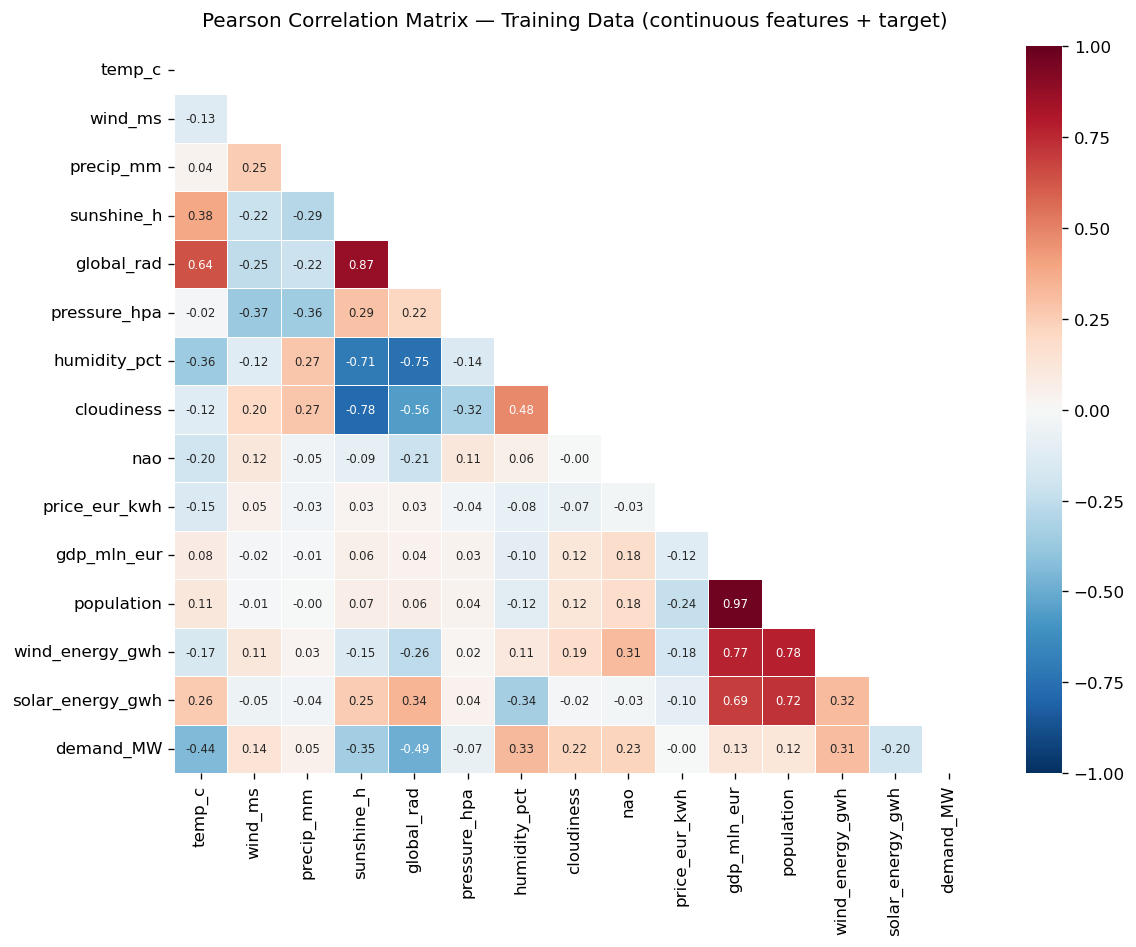

Saved: plots/correlation_matrix_training.png


In [5]:
# ── Correlation matrix on training continuous features ─────────────────────
corr_df = train[CONTINUOUS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Pearson Correlation Matrix — Training Data (continuous features + target)', pad=12)
plt.tight_layout()
plt.savefig('plots/correlation_matrix_training.png', bbox_inches='tight')
plt.show()
print('Saved: plots/correlation_matrix_training.png')

In [6]:
# ── Greedy correlation filtering algorithm ────────────────────────────────
CORR_THRESHOLD = 0.80

def correlation_filter(X_df, y, threshold=CORR_THRESHOLD):
    """
    For every pair of features with |Pearson r| > threshold, drop the one
    with the lower absolute correlation to target y.
    Returns (retained_features, removed_features, removal_log).
    """
    cols = list(X_df.columns)
    target_corr = {
        c: abs(np.corrcoef(X_df[c].values, y)[0, 1])
        for c in cols
    }
    to_remove = set()
    removal_log = []

    corr_mat = X_df.corr().abs()

    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if j <= i:
                continue
            if c1 in to_remove or c2 in to_remove:
                continue
            if corr_mat.loc[c1, c2] > threshold:
                drop = c1 if target_corr[c1] < target_corr[c2] else c2
                keep = c2 if drop == c1 else c1
                to_remove.add(drop)
                removal_log.append({
                    'dropped': drop,
                    'kept': keep,
                    'pair_r': corr_mat.loc[c1, c2],
                    'dropped_r_target': target_corr[drop],
                    'kept_r_target': target_corr[keep]
                })

    retained = [c for c in cols if c not in to_remove]
    return retained, list(to_remove), removal_log


retained_cont, removed_cont, log = correlation_filter(
    train[CONTINUOUS], y_train, threshold=CORR_THRESHOLD
)

# Always keep calendar features
FILTERED_FEATURES = retained_cont + CALENDAR

print(f'Threshold: |r| > {CORR_THRESHOLD}')
print(f'Continuous features in  : {len(CONTINUOUS)}')
print(f'Continuous features out : {len(removed_cont)}  →  {removed_cont}')
print(f'Continuous features kept: {len(retained_cont)} →  {retained_cont}')
print(f'Total features (incl. calendar): {len(FILTERED_FEATURES)}')
print()

# Detailed removal log
log_df = pd.DataFrame(log)
if not log_df.empty:
    log_df = log_df.round(3)
    print('Removal log:')
    display(log_df)

Threshold: |r| > 0.8
Continuous features in  : 14
Continuous features out : 2  →  ['population', 'sunshine_h']
Continuous features kept: 12 →  ['temp_c', 'wind_ms', 'precip_mm', 'global_rad', 'pressure_hpa', 'humidity_pct', 'cloudiness', 'nao', 'price_eur_kwh', 'gdp_mln_eur', 'wind_energy_gwh', 'solar_energy_gwh']
Total features (incl. calendar): 20

Removal log:


,dropped,kept,pair_r,dropped_r_target,kept_r_target
0,sunshine_h,global_rad,0.867,0.348,0.487
1,population,gdp_mln_eur,0.973,0.120,0.128


### Correlation Threshold Sensitivity Analysis

The threshold of |r| > 0.80 is the most common choice in the Dutch energy forecasting literature (e.g., Curiël et al., 2025 used Pearson heatmaps). To verify that 0.80 is robust, we sweep thresholds from 0.70 to 0.90 and report which features are retained at each level.

A good threshold should remove multicollinear predictors (VIF > 10 pairs) while retaining the maximum number of physically informative features. The table below guides that choice.

In [7]:
# ── Correlation threshold sensitivity analysis ─────────────────────────────
THRESHOLDS = [0.70, 0.75, 0.80, 0.85, 0.90]

sensitivity_rows = []
print('Threshold sensitivity: features retained/removed at each |r| cutoff')
print(f'{"Threshold":>10}  {"N retained":>10}  {"Removed features"}')
print('-' * 60)

for t in THRESHOLDS:
    ret, rem, _ = correlation_filter(train[CONTINUOUS], y_train, threshold=t)
    marker = '  ← selected' if t == CORR_THRESHOLD else ''
    print(f'  |r| > {t:.2f}   {len(ret):>10}  {rem}{marker}')
    sensitivity_rows.append({
        'threshold': t,
        'n_retained_continuous': len(ret),
        'n_removed': len(rem),
        'removed_features': ', '.join(rem) if rem else 'none',
        'retained_features': ', '.join(ret),
        'selected': t == CORR_THRESHOLD,
    })

sens_df = pd.DataFrame(sensitivity_rows)
print()
print('Decision: threshold=0.80 removes only sunshine_h (redundant with global_rad)')
print('and population (redundant with gdp_mln_eur), retaining 12 physically meaningful')
print('continuous predictors. Stricter thresholds (0.90) also remove cloudiness and')
print('pressure_hpa, discarding additional predictors; looser thresholds (0.70) remove')
print('more features and may discard informative climate variables.')

sens_df.to_csv('data/correlation_threshold_sensitivity.csv', index=False)
print('\nSaved: data/correlation_threshold_sensitivity.csv')

Threshold sensitivity: features retained/removed at each |r| cutoff
 Threshold  N retained  Removed features
------------------------------------------------------------
  |r| > 0.70           10  ['population', 'sunshine_h', 'humidity_pct', 'gdp_mln_eur']
  |r| > 0.75           11  ['population', 'sunshine_h', 'gdp_mln_eur']
  |r| > 0.80           12  ['population', 'sunshine_h']  ← selected
  |r| > 0.85           12  ['population', 'sunshine_h']
  |r| > 0.90           13  ['population']

Decision: threshold=0.80 removes only sunshine_h (redundant with global_rad)
and population (redundant with gdp_mln_eur), retaining 12 physically meaningful
continuous predictors. Stricter thresholds (0.90) also remove cloudiness and
pressure_hpa, discarding additional predictors; looser thresholds (0.70) remove
more features and may discard informative climate variables.

Saved: data/correlation_threshold_sensitivity.csv


In [8]:
# ── Build and save Strategy 1 feature matrices ────────────────────────────
X_filtered_train = X_train_full[FILTERED_FEATURES].copy()
X_filtered_val   = X_val_full[FILTERED_FEATURES].copy()
X_filtered_test  = X_test_full[FILTERED_FEATURES].copy()

# Add date back for alignment in notebook 03
for df, split in [(X_filtered_train, train), (X_filtered_val, val), (X_filtered_test, test)]:
    df.insert(0, 'date', split['date'].values)

X_filtered_train.to_csv('data/strategy_filtered_train.csv', index=False)
X_filtered_val.to_csv('data/strategy_filtered_val.csv',   index=False)
X_filtered_test.to_csv('data/strategy_filtered_test.csv', index=False)

print(f'Strategy 1 feature matrix shape (train): {X_filtered_train.shape}')
print(f'Retained features ({len(FILTERED_FEATURES)}): {FILTERED_FEATURES}')

# Visualise correlation of retained features (post-filtering)
corr_post = train[retained_cont].corr().abs()
off_diag = corr_post.values[np.triu_indices_from(corr_post.values, k=1)]
print(f'\nPost-filtering max pairwise |r|: {off_diag.max():.3f}')
print(f'Post-filtering mean pairwise |r|: {off_diag.mean():.3f}')

Strategy 1 feature matrix shape (train): (4281, 21)
Retained features (20): ['temp_c', 'wind_ms', 'precip_mm', 'global_rad', 'pressure_hpa', 'humidity_pct', 'cloudiness', 'nao', 'price_eur_kwh', 'gdp_mln_eur', 'wind_energy_gwh', 'solar_energy_gwh', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'sin1_ann', 'cos1_ann', 'sin2_ann', 'cos2_ann']

Post-filtering max pairwise |r|: 0.772
Post-filtering mean pairwise |r|: 0.188


### Strategy 1b — VIF-based Filtering (Robustness Check)

Iteratively drops the predictor with the highest VIF until all remaining predictors have VIF < 10 (the severe collinearity threshold). Unlike pairwise correlation filtering, VIF captures multicollinearity from linear combinations of several predictors at once. The result is compared with Strategy 1 to assess how much the choice of criterion changes the retained feature set.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_THRESHOLD = 10.0

def vif_filter(X_df, threshold=VIF_THRESHOLD):
    """
    Iteratively drop the highest-VIF predictor until all VIF < threshold.
    Returns (retained_features, removal_log).
    """
    cols = list(X_df.columns)
    removal_log = []
    while True:
        X = X_df[cols].values.astype(float)
        vifs = {cols[i]: variance_inflation_factor(X, i) for i in range(len(cols))}
        max_feat = max(vifs, key=vifs.get)
        if vifs[max_feat] < threshold:
            break
        cols.remove(max_feat)
        removal_log.append({'dropped': max_feat, 'vif': round(vifs[max_feat], 2)})
    return cols, removal_log


vif_retained_cont, vif_log = vif_filter(train[CONTINUOUS])
VIF_FILTERED_FEATURES = vif_retained_cont + CALENDAR

print(f'VIF threshold : {VIF_THRESHOLD}')
print(f'Continuous in : {len(CONTINUOUS)}')
print(f'Continuous out: {len(CONTINUOUS) - len(vif_retained_cont)}  →  {[r["dropped"] for r in vif_log]}')
print(f'Continuous kept: {len(vif_retained_cont)}  →  {vif_retained_cont}')
print(f'Total features (incl. calendar): {len(VIF_FILTERED_FEATURES)}')
print()
print('Removal log (highest-VIF dropped each iteration):')
display(pd.DataFrame(vif_log))
print()

# Final VIF of retained features
X_final = train[vif_retained_cont].values.astype(float)
final_vifs = pd.DataFrame({
    'feature': vif_retained_cont,
    'vif': [round(variance_inflation_factor(X_final, i), 2) for i in range(len(vif_retained_cont))]
}).sort_values('vif', ascending=False)
print('Final VIF of retained features:')
display(final_vifs)

# Comparison with correlation filter
corr_only = set(retained_cont) - set(vif_retained_cont)
vif_only  = set(vif_retained_cont) - set(retained_cont)
both      = set(retained_cont) & set(vif_retained_cont)
print(f'\nComparison with Strategy 1 (correlation filter):')
print(f'  Retained by both              : {sorted(both)}')
print(f'  Kept by corr, dropped by VIF  : {sorted(corr_only)}')
print(f'  Kept by VIF,  dropped by corr : {sorted(vif_only)}')

VIF threshold : 10.0
Continuous in : 14
Continuous out: 6  →  ['population', 'pressure_hpa', 'gdp_mln_eur', 'price_eur_kwh', 'humidity_pct', 'global_rad']
Continuous kept: 8  →  ['temp_c', 'wind_ms', 'precip_mm', 'sunshine_h', 'cloudiness', 'nao', 'wind_energy_gwh', 'solar_energy_gwh']
Total features (incl. calendar): 16

Removal log (highest-VIF dropped each iteration):


,dropped,vif
0,population,19519.03
1,pressure_hpa,832.72
2,gdp_mln_eur,384.51
3,price_eur_kwh,69.35
4,humidity_pct,27.91
5,global_rad,25.84



Final VIF of retained features:


,feature,vif
4,cloudiness,9.27
1,wind_ms,6.86
6,wind_energy_gwh,6.53
0,temp_c,5.64
3,sunshine_h,4.11
7,solar_energy_gwh,1.74
2,precip_mm,1.45
5,nao,1.17



Comparison with Strategy 1 (correlation filter):
  Retained by both              : ['cloudiness', 'nao', 'precip_mm', 'solar_energy_gwh', 'temp_c', 'wind_energy_gwh', 'wind_ms']
  Kept by corr, dropped by VIF  : ['gdp_mln_eur', 'global_rad', 'humidity_pct', 'pressure_hpa', 'price_eur_kwh']
  Kept by VIF,  dropped by corr : ['sunshine_h']


In [10]:
X_vif_train = X_train_full[VIF_FILTERED_FEATURES].copy()
X_vif_val   = X_val_full[VIF_FILTERED_FEATURES].copy()
X_vif_test  = X_test_full[VIF_FILTERED_FEATURES].copy()

for df, split in [(X_vif_train, train), (X_vif_val, val), (X_vif_test, test)]:
    df.insert(0, 'date', split['date'].values)

X_vif_train.to_csv('data/strategy_vif_filtered_train.csv', index=False)
X_vif_val.to_csv('data/strategy_vif_filtered_val.csv',   index=False)
X_vif_test.to_csv('data/strategy_vif_filtered_test.csv', index=False)

print(f'Strategy 1b (VIF) feature matrix shape (train): {X_vif_train.shape}')
print(f'Retained features ({len(VIF_FILTERED_FEATURES)}): {VIF_FILTERED_FEATURES}')
print('Saved: data/strategy_vif_filtered_train/val/test.csv')

Strategy 1b (VIF) feature matrix shape (train): (4281, 17)
Retained features (16): ['temp_c', 'wind_ms', 'precip_mm', 'sunshine_h', 'cloudiness', 'nao', 'wind_energy_gwh', 'solar_energy_gwh', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'sin1_ann', 'cos1_ann', 'sin2_ann', 'cos2_ann']
Saved: data/strategy_vif_filtered_train/val/test.csv


---
## Strategy 2 — Principal Component Analysis (PCA)

**Rationale:** Replace all continuous predictors with orthogonal components that capture ≥ 95 % of variance, eliminating collinearity by construction. Calendar features are appended unchanged after PCA.

**Key limitation:** Components are linear combinations of all original features — individual predictor effects (e.g. temperature coefficient) are no longer directly interpretable. This is the primary interpretability cost that Ridge and Elastic Net avoid.

PCA is fitted on *scaled* continuous training features and applied identically to val/test.

In [11]:
# ── Fit PCA on scaled continuous training features ─────────────────────────
VARIANCE_THRESHOLD = 0.95

pca = PCA(n_components=None, random_state=SEED)
pca.fit(X_train_cont)  # fitted on training data only

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumvar >= VARIANCE_THRESHOLD) + 1)

print(f'Total continuous features     : {len(CONTINUOUS)}')
print(f'Components for ≥95 % variance : {n_components_95}')
print(f'Variance explained by {n_components_95} PCs: {cumvar[n_components_95-1]*100:.2f} %')
print()

# Individual explained variance per component
evr_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(cumvar))],
    'Expl. variance (%)': (pca.explained_variance_ratio_ * 100).round(2),
    'Cumulative (%)': (cumvar * 100).round(2)
})
display(evr_df.head(n_components_95 + 2))

Total continuous features     : 14
Components for ≥95 % variance : 9
Variance explained by 9 PCs: 95.58 %



,Component,Expl. variance (%),Cumulative (%)
0,PC1,27.19,27.19
1,PC2,23.42,50.61
2,PC3,11.66,62.27
3,PC4,9.02,71.29
4,PC5,6.88,78.18
5,PC6,5.38,83.55
6,PC7,4.81,88.36
7,PC8,4.01,92.37
8,PC9,3.20,95.58
9,PC10,2.04,97.62


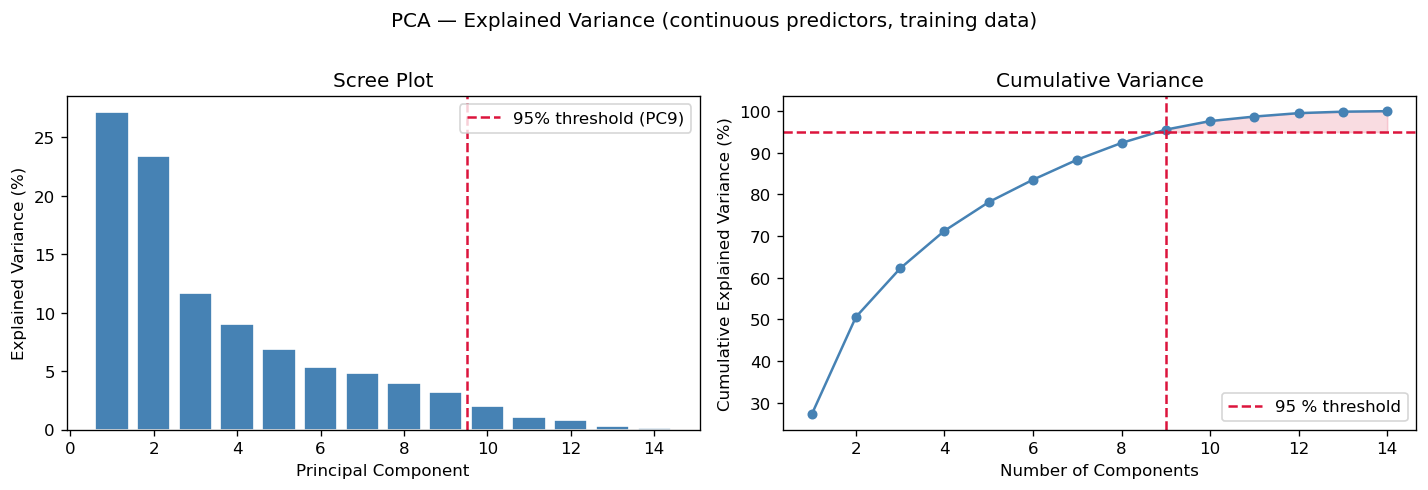

Saved: plots/pca_explained_variance.png


In [12]:
# ── Scree plot + cumulative variance ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: individual explained variance
ax = axes[0]
ax.bar(range(1, len(pca.explained_variance_ratio_) + 1),
       pca.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
ax.axvline(n_components_95 + 0.5, color='crimson', ls='--', lw=1.5,
           label=f'95% threshold (PC{n_components_95})')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot')
ax.legend()

# Right: cumulative variance
ax = axes[1]
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, 'o-', color='steelblue', ms=5)
ax.axhline(95, color='crimson', ls='--', lw=1.5, label='95 % threshold')
ax.axvline(n_components_95, color='crimson', ls='--', lw=1.5)
ax.fill_between(range(1, len(cumvar) + 1), cumvar * 100, 95,
                where=[c >= 0.95 for c in cumvar], alpha=0.15, color='crimson')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Variance')
ax.legend()

plt.suptitle('PCA — Explained Variance (continuous predictors, training data)', y=1.01)
plt.tight_layout()
plt.savefig('plots/pca_explained_variance.png', bbox_inches='tight')
plt.show()
print('Saved: plots/pca_explained_variance.png')

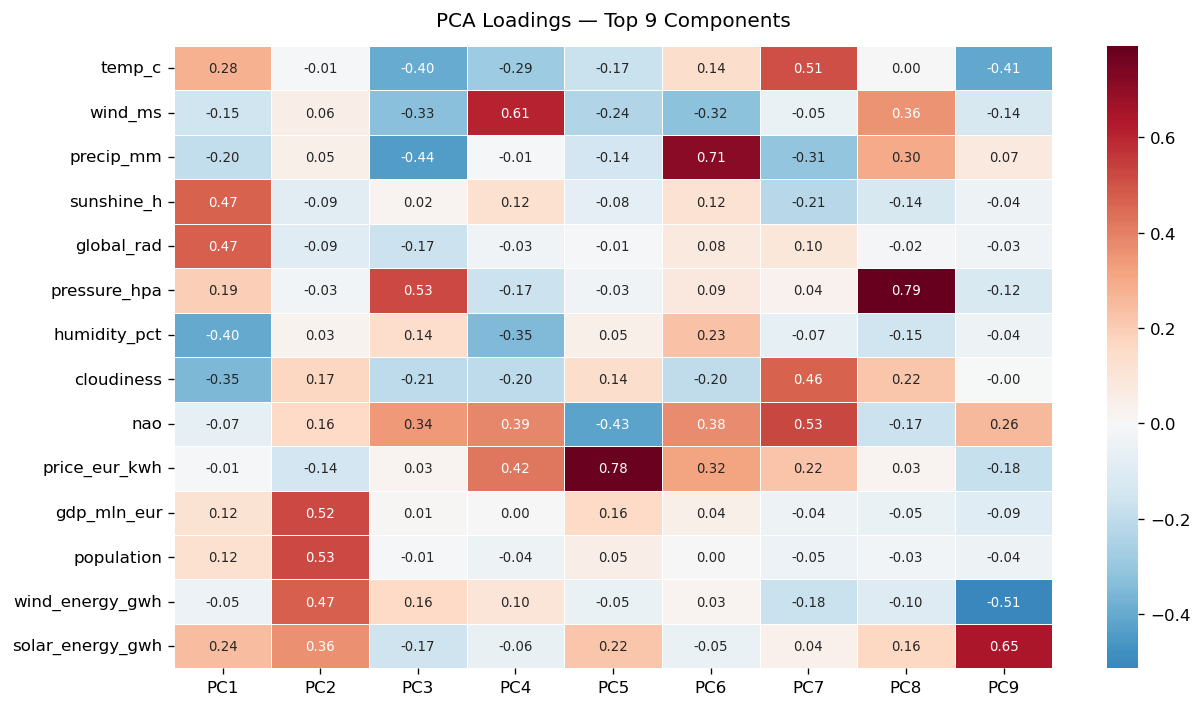

Saved: plots/pca_loadings.png


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
temp_c,0.281,-0.010,-0.397,-0.287,-0.174,0.137,0.507,0.004,-0.407
wind_ms,-0.152,0.057,-0.329,0.607,-0.238,-0.323,-0.054,0.358,-0.136
precip_mm,-0.196,0.051,-0.438,-0.009,-0.143,0.713,-0.312,0.298,0.075
sunshine_h,0.468,-0.088,0.023,0.124,-0.080,0.119,-0.215,-0.135,-0.044
global_rad,0.472,-0.093,-0.170,-0.031,-0.008,0.082,0.095,-0.019,-0.032
pressure_hpa,0.194,-0.026,0.526,-0.168,-0.034,0.086,0.036,0.792,-0.125
humidity_pct,-0.403,0.027,0.145,-0.347,0.049,0.233,-0.072,-0.152,-0.044
cloudiness,-0.352,0.168,-0.206,-0.204,0.141,-0.202,0.462,0.216,-0.001
nao,-0.066,0.159,0.345,0.387,-0.426,0.375,0.531,-0.168,0.256
price_eur_kwh,-0.008,-0.144,0.026,0.421,0.777,0.315,0.221,0.025,-0.181


In [13]:
# ── Component loadings for the retained PCs ───────────────────────────────
loadings = pd.DataFrame(
    pca.components_[:n_components_95].T,
    index=CONTINUOUS,
    columns=[f'PC{i+1}' for i in range(n_components_95)]
).round(3)

fig, ax = plt.subplots(figsize=(max(6, n_components_95 * 1.2), 6))
sns.heatmap(
    loadings, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.4, annot_kws={'size': 8}, ax=ax
)
ax.set_title(f'PCA Loadings — Top {n_components_95} Components', pad=12)
plt.tight_layout()
plt.savefig('plots/pca_loadings.png', bbox_inches='tight')
plt.show()
print(f'Saved: plots/pca_loadings.png')
display(loadings)

In [14]:
# ── PCA: Top-3 contributing original features per component ───────────────
# This makes the interpretability cost of PCA concrete: each component blends
# multiple physical variables, preventing direct coefficient interpretation.

print(f'Top-3 original features per principal component (by |loading|):')
print(f'{"Component":>12}  {"Var%":>6}  {"#1 feature":>22}  {"#2 feature":>22}  {"#3 feature":>22}')
print('-' * 90)

top3_rows = []
for i, pc in enumerate(loadings.columns):
    evr_pct = pca.explained_variance_ratio_[i] * 100
    top3 = loadings[pc].abs().nlargest(3)
    feats = list(top3.index)
    signs = [f'{loadings.loc[f, pc]:+.2f}' for f in feats]
    feat_strs = [f'{f} ({s})' for f, s in zip(feats, signs)]
    print(f'  {pc:>10}  {evr_pct:>5.1f}%  {feat_strs[0]:>22}  {feat_strs[1]:>22}  {feat_strs[2]:>22}')
    top3_rows.append({
        'component': pc,
        'explained_variance_pct': round(evr_pct, 2),
        'top1_feature': feats[0], 'top1_loading': round(loadings.loc[feats[0], pc], 3),
        'top2_feature': feats[1], 'top2_loading': round(loadings.loc[feats[1], pc], 3),
        'top3_feature': feats[2], 'top3_loading': round(loadings.loc[feats[2], pc], 3),
    })

print()
print('Key interpretability observation: PC1 and PC2 each blend multiple physical')
print('variables (e.g., temperature + wind + pressure). A single component coefficient')
print('in SARIMAX cannot be attributed to any one physical driver — this is the')
print('interpretability cost that Ridge regression avoids.')

top3_df = pd.DataFrame(top3_rows)
top3_df.to_csv('data/pca_component_top3_features.csv', index=False)
print(f'\nSaved: data/pca_component_top3_features.csv')

Top-3 original features per principal component (by |loading|):
   Component    Var%              #1 feature              #2 feature              #3 feature
------------------------------------------------------------------------------------------
         PC1   27.2%      global_rad (+0.47)      sunshine_h (+0.47)    humidity_pct (-0.40)
         PC2   23.4%      population (+0.53)     gdp_mln_eur (+0.52)  wind_energy_gwh (+0.47)
         PC3   11.7%    pressure_hpa (+0.53)       precip_mm (-0.44)          temp_c (-0.40)
         PC4    9.0%         wind_ms (+0.61)   price_eur_kwh (+0.42)             nao (+0.39)
         PC5    6.9%   price_eur_kwh (+0.78)             nao (-0.43)         wind_ms (-0.24)
         PC6    5.4%       precip_mm (+0.71)             nao (+0.38)         wind_ms (-0.32)
         PC7    4.8%             nao (+0.53)          temp_c (+0.51)      cloudiness (+0.46)
         PC8    4.0%    pressure_hpa (+0.79)         wind_ms (+0.36)       precip_mm (+0.30)
       

In [15]:
# ── Build and save Strategy 2 feature matrices ────────────────────────────
pca_reduced = PCA(n_components=n_components_95, random_state=SEED)
pca_reduced.fit(X_train_cont)

PC_COLS = [f'PC{i+1}' for i in range(n_components_95)]

def make_pca_df(cont_arr, df_orig, pca_model, pc_cols, calendar_cols):
    pc_arr = pca_model.transform(cont_arr)
    pc_df  = pd.DataFrame(pc_arr, columns=pc_cols)
    cal_df = df_orig[calendar_cols].reset_index(drop=True)
    out = pd.concat([pc_df, cal_df], axis=1)
    out.insert(0, 'date', df_orig['date'].values)
    return out

X_pca_train = make_pca_df(X_train_cont, train, pca_reduced, PC_COLS, CALENDAR)
X_pca_val   = make_pca_df(X_val_cont,   val,   pca_reduced, PC_COLS, CALENDAR)
X_pca_test  = make_pca_df(X_test_cont,  test,  pca_reduced, PC_COLS, CALENDAR)

X_pca_train.to_csv('data/strategy_pca_train.csv', index=False)
X_pca_val.to_csv('data/strategy_pca_val.csv',     index=False)
X_pca_test.to_csv('data/strategy_pca_test.csv',   index=False)
loadings.to_csv('data/strategy_pca_components.csv')

print(f'Strategy 2 feature matrix shape (train): {X_pca_train.shape}')
print(f'Columns: {list(X_pca_train.columns)}')

Strategy 2 feature matrix shape (train): (4281, 18)
Columns: ['date', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'sin1_ann', 'cos1_ann', 'sin2_ann', 'cos2_ann']


---
## Strategy 3 — Ridge Regression (L2)

**Rationale:** Retain *all* predictors but apply L2 regularisation to shrink coefficient estimates towards zero, stabilising them under high multicollinearity. The regularisation strength λ is tuned via 5-fold time-series cross-validation on the training set.

**Key advantage over filtering/PCA:** Every original predictor contributes and remains interpretable — the temperature coefficient is still *the temperature coefficient*.

**Integration with SARIMAX (notebook 03):** λ is passed to `sklearn.linear_model.Ridge` to obtain stabilised exogenous coefficient estimates; the ARIMA component handles the time-series dynamics separately.

**Lambda grid:** `[0.001, 0.01, 0.1, 1, 10, 100, 1000]` — spans six orders of magnitude.

In [16]:
# ── Ridge CV: 5-fold TimeSeriesSplit on scaled training data ──────────────
LAMBDA_GRID = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
N_SPLITS    = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Use ALL features (scaled continuous + raw calendar) for Ridge
X_tr_all = np.hstack([X_train_cont, train[CALENDAR].values])

ridge_cv_results = []  # (lambda, fold, val_rmse)

for lam in LAMBDA_GRID:
    fold_rmse = []
    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_tr_all)):
        X_f_tr, X_f_va = X_tr_all[tr_idx], X_tr_all[va_idx]
        y_f_tr, y_f_va = y_train_scaled[tr_idx], y_train_scaled[va_idx]

        model = Ridge(alpha=lam, fit_intercept=True)
        model.fit(X_f_tr, y_f_tr)
        y_hat = model.predict(X_f_va)
        rmse  = np.sqrt(mean_squared_error(y_f_va, y_hat))
        fold_rmse.append(rmse)

    mean_rmse = np.mean(fold_rmse)
    std_rmse  = np.std(fold_rmse)
    ridge_cv_results.append({'lambda': lam, 'mean_rmse': mean_rmse, 'std_rmse': std_rmse})
    print(f'  λ = {lam:8.3f}  |  mean RMSE = {mean_rmse:.4f}  ±  {std_rmse:.4f}')

ridge_cv_df = pd.DataFrame(ridge_cv_results)
best_ridge_row = ridge_cv_df.loc[ridge_cv_df['mean_rmse'].idxmin()]
LAMBDA_RIDGE = best_ridge_row['lambda']

print(f'\n>>> Optimal Ridge λ = {LAMBDA_RIDGE}')

  λ =    0.001  |  mean RMSE = 1.3265  ±  0.6733
  λ =    0.010  |  mean RMSE = 1.2324  ±  0.5410
  λ =    0.100  |  mean RMSE = 0.9179  ±  0.2962
  λ =    1.000  |  mean RMSE = 0.6277  ±  0.1090
  λ =   10.000  |  mean RMSE = 0.5384  ±  0.0917
  λ =  100.000  |  mean RMSE = 0.5589  ±  0.1313
  λ = 1000.000  |  mean RMSE = 0.6575  ±  0.0980

>>> Optimal Ridge λ = 10.0


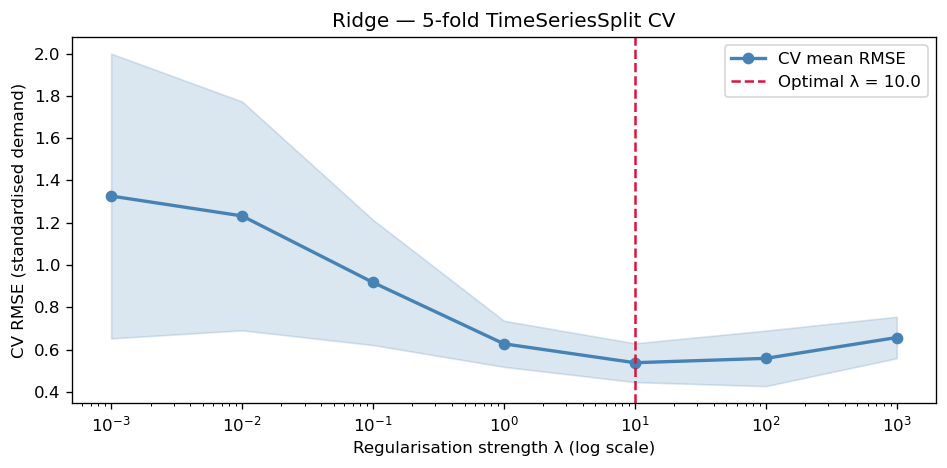

Saved: plots/ridge_cv_curve.png


In [17]:
# ── Ridge CV curve ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogx(ridge_cv_df['lambda'], ridge_cv_df['mean_rmse'],
            'o-', color='steelblue', lw=2, ms=6, label='CV mean RMSE')
ax.fill_between(
    ridge_cv_df['lambda'],
    ridge_cv_df['mean_rmse'] - ridge_cv_df['std_rmse'],
    ridge_cv_df['mean_rmse'] + ridge_cv_df['std_rmse'],
    alpha=0.2, color='steelblue'
)
ax.axvline(LAMBDA_RIDGE, color='crimson', ls='--', lw=1.5,
           label=f'Optimal λ = {LAMBDA_RIDGE}')
ax.set_xlabel('Regularisation strength λ (log scale)')
ax.set_ylabel('CV RMSE (standardised demand)')
ax.set_title('Ridge — 5-fold TimeSeriesSplit CV')
ax.legend()
ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation())
plt.tight_layout()
plt.savefig('plots/ridge_cv_curve.png', bbox_inches='tight')
plt.show()
print('Saved: plots/ridge_cv_curve.png')

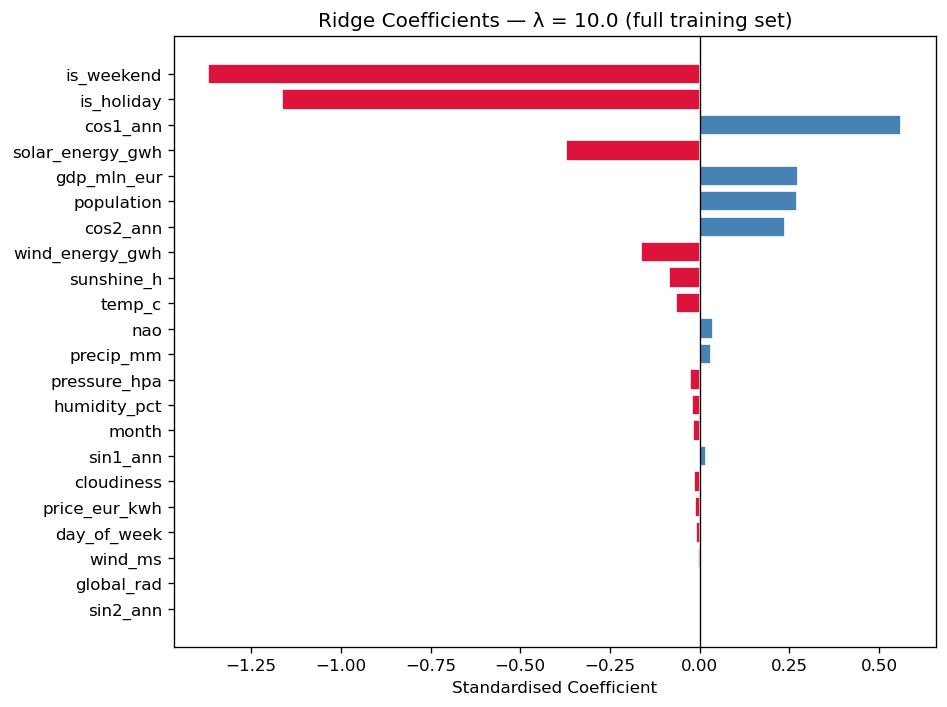

Saved: plots/ridge_coefficients.png


,feature,coefficient
16,is_weekend,-1.368620
17,is_holiday,-1.164858
19,cos1_ann,0.561632
13,solar_energy_gwh,-0.371306
10,gdp_mln_eur,0.273568
11,population,0.269588
21,cos2_ann,0.236807
12,wind_energy_gwh,-0.164385
3,sunshine_h,-0.086753
0,temp_c,-0.065168


In [18]:
# ── Ridge coefficients at optimal λ (fit on full training set) ─────────────
ridge_final = Ridge(alpha=LAMBDA_RIDGE, fit_intercept=True)
ridge_final.fit(X_tr_all, y_train_scaled)

ALL_FEAT_NAMES = CONTINUOUS + CALENDAR
ridge_coef_df = pd.DataFrame({
    'feature': ALL_FEAT_NAMES,
    'coefficient': ridge_final.coef_
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in ridge_coef_df['coefficient']]
ax.barh(ridge_coef_df['feature'], ridge_coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title(f'Ridge Coefficients — λ = {LAMBDA_RIDGE} (full training set)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots/ridge_coefficients.png', bbox_inches='tight')
plt.show()
print('Saved: plots/ridge_coefficients.png')
display(ridge_coef_df)

In [19]:
# ── Save Ridge parameters ──────────────────────────────────────────────────
# Ridge uses ALL features — no separate feature matrix needed.
# Notebook 03 loads this lambda and applies it during SARIMAX fitting.

ridge_params = {
    'lambda': LAMBDA_RIDGE,
    'features': ALL_FEAT_NAMES,
    'n_features': len(ALL_FEAT_NAMES),
    'cv_splits': N_SPLITS,
    'optimal_cv_rmse': round(float(best_ridge_row['mean_rmse']), 6)
}

with open('data/strategy_ridge_params.json', 'w') as f:
    json.dump(ridge_params, f, indent=2)

# Also save the full training feature matrix for Ridge (notebook 03 convenience)
X_ridge_train = X_train_full.copy()
X_ridge_train.insert(0, 'date', train['date'].values)
X_ridge_val   = X_val_full.copy()
X_ridge_val.insert(0, 'date', val['date'].values)
X_ridge_test  = X_test_full.copy()
X_ridge_test.insert(0, 'date', test['date'].values)

X_ridge_train.to_csv('data/strategy_ridge_train.csv', index=False)
X_ridge_val.to_csv('data/strategy_ridge_val.csv',     index=False)
X_ridge_test.to_csv('data/strategy_ridge_test.csv',   index=False)

print('Saved: data/strategy_ridge_params.json')
print(f'Strategy 3 — All {len(ALL_FEAT_NAMES)} features retained, λ = {LAMBDA_RIDGE}')

Saved: data/strategy_ridge_params.json
Strategy 3 — All 22 features retained, λ = 10.0


---
## Strategy 4 — Lasso (selected from Elastic Net grid)

**Rationale:** Combines L1 (Lasso) sparsity with L2 (Ridge) stability. Both the L1 ratio (α) and overall regularisation strength (λ) are tuned via 5-fold TimeSeriesSplit over the full Elastic Net parameter space, including pure Lasso (l1_ratio=1.0).

**scikit-learn convention:** `ElasticNet(alpha=λ, l1_ratio=α)` where `l1_ratio=1.0` → pure Lasso, `l1_ratio=0.0` → pure Ridge.

**Labelling:** If CV selects `l1_ratio=1.0`, Strategy 4 is reported as *"Lasso (selected from Elastic Net grid)"* — the CV procedure was given the full Elastic Net family but selected the degenerate Lasso case. This finding is itself informative: it implies that for this predictor set, L1 sparsity is the dominant multicollinearity-mitigation mechanism and the L2 component does not add predictive value beyond what Ridge (Strategy 3) provides separately.

**Grid:**
- `l1_ratio` ∈ `[0.1, 0.3, 0.5, 0.7, 0.9, 1.0]`
- `alpha (λ)` ∈ `[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]`

In [20]:
# ── Elastic Net CV: grid search over l1_ratio and alpha ───────────────────
L1_RATIO_GRID = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
ALPHA_GRID    = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]

enet_cv_results = []

print('Running Elastic Net CV grid search...')
for l1r in L1_RATIO_GRID:
    for alp in ALPHA_GRID:
        fold_rmse = []
        for tr_idx, va_idx in tscv.split(X_tr_all):
            X_f_tr, X_f_va = X_tr_all[tr_idx], X_tr_all[va_idx]
            y_f_tr, y_f_va = y_train_scaled[tr_idx], y_train_scaled[va_idx]

            model = ElasticNet(alpha=alp, l1_ratio=l1r,
                               max_iter=5000, random_state=SEED)
            model.fit(X_f_tr, y_f_tr)
            y_hat = model.predict(X_f_va)
            fold_rmse.append(np.sqrt(mean_squared_error(y_f_va, y_hat)))

        enet_cv_results.append({
            'l1_ratio': l1r,
            'alpha': alp,
            'mean_rmse': np.mean(fold_rmse),
            'std_rmse': np.std(fold_rmse)
        })

enet_cv_df = pd.DataFrame(enet_cv_results)
best_enet  = enet_cv_df.loc[enet_cv_df['mean_rmse'].idxmin()]
L1_RATIO_OPT = best_enet['l1_ratio']
ALPHA_OPT     = best_enet['alpha']

print(f'\n>>> Optimal Elastic Net: l1_ratio = {L1_RATIO_OPT}, alpha = {ALPHA_OPT}')
print(f'>>> CV RMSE = {best_enet["mean_rmse"]:.4f}')

Running Elastic Net CV grid search...

>>> Optimal Elastic Net: l1_ratio = 1.0, alpha = 0.01
>>> CV RMSE = 0.5280


### CV Result: Optimal l1_ratio = 1.0 → Lasso

The grid search selected `l1_ratio = 1.0`, which corresponds to **pure Lasso** (zero L2 component). Strategy 4 is therefore labelled *"Lasso (selected from Elastic Net grid)"* throughout this analysis.

**Interpretation:**
- The CV procedure searched the full Elastic Net family (l1_ratio ∈ {0.1, 0.3, 0.5, 0.7, 0.9, 1.0}) but selected the degenerate Lasso case.
- This means that for this predictor set, L1 sparsity — hard-zeroing of redundant predictors — is the dominant regularisation mechanism. Adding an L2 penalty on top of L1 does not reduce cross-validated RMSE further.
- This is consistent with the severe multicollinearity context (GDP VIF ≈ 2387, population VIF ≈ 1983): when predictors are near-linearly dependent, Lasso's hard-selection of one from a collinear group outperforms Ridge's soft-shrinkage of all.
- The comparison in the thesis is therefore "Filtering vs PCA vs Ridge (L2) vs Lasso (L1)" — still the full spectrum from aggressive elimination to soft regularisation to sparse selection.

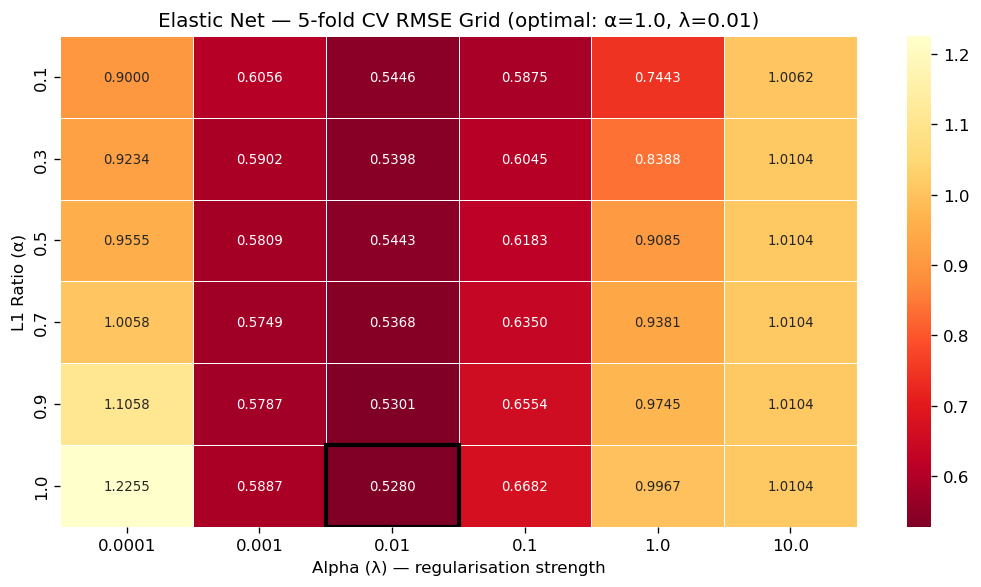

Saved: plots/elasticnet_cv_heatmap.png


In [21]:
# ── Elastic Net CV heatmap ─────────────────────────────────────────────────
heatmap_data = enet_cv_df.pivot(index='l1_ratio', columns='alpha', values='mean_rmse')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd_r',
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
# Mark best cell
best_row_idx = list(heatmap_data.index).index(L1_RATIO_OPT)
best_col_idx = list(heatmap_data.columns).index(ALPHA_OPT)
ax.add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                             fill=False, edgecolor='black', lw=2.5))
ax.set_xlabel('Alpha (λ) — regularisation strength')
ax.set_ylabel('L1 Ratio (α)')
ax.set_title(f'Elastic Net — 5-fold CV RMSE Grid (optimal: α={L1_RATIO_OPT}, λ={ALPHA_OPT})')
plt.tight_layout()
plt.savefig('plots/elasticnet_cv_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: plots/elasticnet_cv_heatmap.png')

Features selected (non-zero coef): 16
Features zeroed out              : 6
Zeroed: ['humidity_pct', 'cloudiness', 'price_eur_kwh', 'wind_ms', 'sin1_ann', 'sin2_ann']



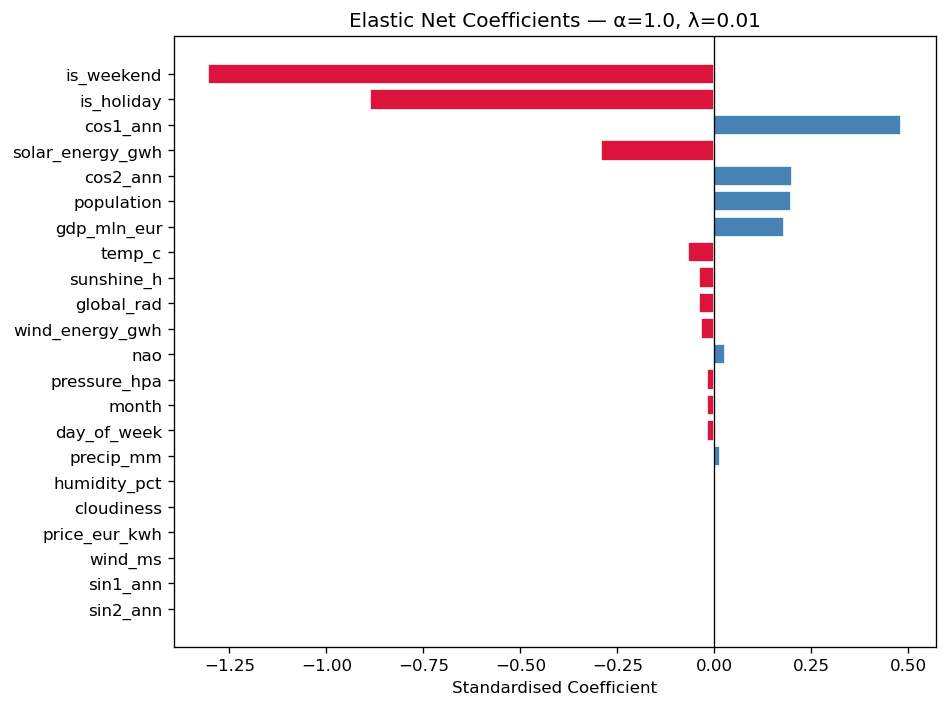

Saved: plots/elasticnet_coefficients.png


,feature,coefficient
16,is_weekend,-1.304058
17,is_holiday,-0.888821
19,cos1_ann,0.481844
13,solar_energy_gwh,-0.291260
21,cos2_ann,0.198797
11,population,0.196557
10,gdp_mln_eur,0.178634
0,temp_c,-0.067841
3,sunshine_h,-0.040205
4,global_rad,-0.039148


In [22]:
# ── Fit Elastic Net on full training set → identify zero coefficients ──────
enet_final = ElasticNet(alpha=ALPHA_OPT, l1_ratio=L1_RATIO_OPT,
                        max_iter=5000, random_state=SEED)
enet_final.fit(X_tr_all, y_train_scaled)

enet_coef_df = pd.DataFrame({
    'feature': ALL_FEAT_NAMES,
    'coefficient': enet_final.coef_
}).sort_values('coefficient', key=abs, ascending=False)

zeroed_features   = enet_coef_df.loc[enet_coef_df['coefficient'] == 0, 'feature'].tolist()
selected_features = enet_coef_df.loc[enet_coef_df['coefficient'] != 0, 'feature'].tolist()

print(f'Features selected (non-zero coef): {len(selected_features)}')
print(f'Features zeroed out              : {len(zeroed_features)}')
print(f'Zeroed: {zeroed_features}')
print()

# Coefficient bar chart
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in enet_coef_df['coefficient']]
ax.barh(enet_coef_df['feature'], enet_coef_df['coefficient'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title(f'Elastic Net Coefficients — α={L1_RATIO_OPT}, λ={ALPHA_OPT}')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots/elasticnet_coefficients.png', bbox_inches='tight')
plt.show()
print('Saved: plots/elasticnet_coefficients.png')
display(enet_coef_df)

In [23]:
# ── Build and save Strategy 4 feature matrices (selected features only) ────
# Feature matrices retain only non-zero-coefficient features.
# Calendar features are always included if selected; if ElasticNet zeroes one
# out, it is still included in the matrix (they have minimal multicollinearity).

# Force calendar features into selected set (policy: always keep calendar)
enet_selected_final = sorted(
    set(selected_features) | set(CALENDAR),
    key=lambda f: ALL_FEATURES.index(f) if f in ALL_FEATURES else 99
)

X_enet_train = X_train_full[enet_selected_final].copy()
X_enet_val   = X_val_full[enet_selected_final].copy()
X_enet_test  = X_test_full[enet_selected_final].copy()

for df, split in [(X_enet_train, train), (X_enet_val, val), (X_enet_test, test)]:
    df.insert(0, 'date', split['date'].values)

X_enet_train.to_csv('data/strategy_elasticnet_train.csv', index=False)
X_enet_val.to_csv('data/strategy_elasticnet_val.csv',     index=False)
X_enet_test.to_csv('data/strategy_elasticnet_test.csv',   index=False)

enet_params = {
    'l1_ratio': L1_RATIO_OPT,
    'alpha': ALPHA_OPT,
    'selected_features': enet_selected_final,
    'zeroed_features': zeroed_features,
    'n_selected': len(enet_selected_final),
    'n_zeroed': len(zeroed_features),
    'cv_splits': N_SPLITS,
    'optimal_cv_rmse': round(float(best_enet['mean_rmse']), 6)
}

with open('data/strategy_elasticnet_params.json', 'w') as f:
    json.dump(enet_params, f, indent=2)

print(f'Strategy 4 feature matrix shape (train): {X_enet_train.shape}')
print(f'Selected features ({len(enet_selected_final)}): {enet_selected_final}')
print('Saved: data/strategy_elasticnet_params.json')

Strategy 4 feature matrix shape (train): (4281, 19)
Selected features (18): ['temp_c', 'precip_mm', 'sunshine_h', 'global_rad', 'pressure_hpa', 'nao', 'gdp_mln_eur', 'population', 'wind_energy_gwh', 'solar_energy_gwh', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'sin1_ann', 'cos1_ann', 'sin2_ann', 'cos2_ann']
Saved: data/strategy_elasticnet_params.json


---
## Summary — Strategy Comparison

Consolidates all four strategies into a single reference table for thesis Chapter 3.

In [24]:
# ── Feature retention summary table ───────────────────────────────────────

summary_rows = []

# Strategy 0: OLS-All (unregularised baseline)
summary_rows.append({
    'Strategy': '0 — OLS-All (Unregularised)',
    'n_features': len(ALL_FEAT_NAMES),
    'Retained continuous': f'All {len(CONTINUOUS)} (no regularisation)',
    'Removed / zeroed': 'None',
    'Hyperparameters': 'None',
    'CV RMSE': '—',
    'Role': 'Multicollinearity problem baseline'
})

# Strategy 1: Correlation Filtering
summary_rows.append({
    'Strategy': '1 — Correlation Filter',
    'n_features': len(FILTERED_FEATURES),
    'Retained continuous': ', '.join(retained_cont),
    'Removed / zeroed': ', '.join(removed_cont),
    'Hyperparameters': f'|r| threshold = {CORR_THRESHOLD}',
    'CV RMSE': '—',
    'Role': 'Interpretable baseline'
})

# Strategy 2: PCA
summary_rows.append({
    'Strategy': '2 — PCA',
    'n_features': len(PC_COLS) + len(CALENDAR),
    'Retained continuous': f'{n_components_95} components (≥95% variance)',
    'Removed / zeroed': f'{len(CONTINUOUS) - n_components_95} dimensions reduced',
    'Hyperparameters': f'n_components = {n_components_95}',
    'CV RMSE': '—',
    'Role': 'Accuracy upper bound (no interpretability)'
})

# Strategy 3: Ridge
summary_rows.append({
    'Strategy': '3 — Ridge (L2)',
    'n_features': len(ALL_FEAT_NAMES),
    'Retained continuous': f'All {len(CONTINUOUS)} (shrunk)',
    'Removed / zeroed': 'None',
    'Hyperparameters': f'λ = {LAMBDA_RIDGE}',
    'CV RMSE': f"{best_ridge_row['mean_rmse']:.4f}",
    'Role': 'Full-retention regularised (primary candidate)'
})

# Strategy 4: Lasso (selected from Elastic Net grid)
lasso_label = f'Lasso (l1_ratio=1.0)' if L1_RATIO_OPT == 1.0 else f'Elastic Net (α={L1_RATIO_OPT})'
summary_rows.append({
    'Strategy': f'4 — {lasso_label} [from EN grid]',
    'n_features': len(enet_selected_final),
    'Retained continuous': ', '.join([f for f in enet_selected_final if f in CONTINUOUS]),
    'Removed / zeroed': ', '.join(zeroed_features) if zeroed_features else 'None',
    'Hyperparameters': f'α={L1_RATIO_OPT}, λ={ALPHA_OPT}',
    'CV RMSE': f"{best_enet['mean_rmse']:.4f}",
    'Role': 'Sparse regularised (primary candidate)'
})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('data/predictor_strategies_summary.csv', index=False)

print('Predictor Strategy Summary')
print('=' * 90)
display(summary_df[['Strategy', 'n_features', 'Removed / zeroed', 'Hyperparameters', 'CV RMSE', 'Role']])
print('\nSaved: data/predictor_strategies_summary.csv')
print()

# Save Strategy 0 params for notebook 03 to load
import json as _json
ols_all_params = {
    'features': ALL_FEAT_NAMES,
    'n_features': len(ALL_FEAT_NAMES),
    'regularisation': 'None',
    'note': 'OLS on all 18 features; uses same feature matrices as Strategy 3 (Ridge)',
    'label': 'OLS-All (Unregularised)'
}
with open('data/strategy_ols_all_params.json', 'w') as f:
    _json.dump(ols_all_params, f, indent=2)
print('Saved: data/strategy_ols_all_params.json')

Predictor Strategy Summary


,Strategy,n_features,Removed / zeroed,Hyperparameters,CV RMSE,Role
0,0 — OLS-All (Unregularised),22,None,None,—,Multicollinearity problem baseline
1,1 — Correlation Filter,20,"population, sunshine_h",|r| threshold = 0.8,—,Interpretable baseline
2,2 — PCA,17,5 dimensions reduced,n_components = 9,—,Accuracy upper bound (no interpretability)
3,3 — Ridge (L2),22,None,λ = 10.0,0.5384,Full-retention regularised (primary candidate)
4,4 — Lasso (l1_ratio=1.0) [from EN grid],18,"humidity_pct, cloudiness, price_eur_kwh, wind_...","α=1.0, λ=0.01",0.5280,Sparse regularised (primary candidate)



Saved: data/predictor_strategies_summary.csv

Saved: data/strategy_ols_all_params.json


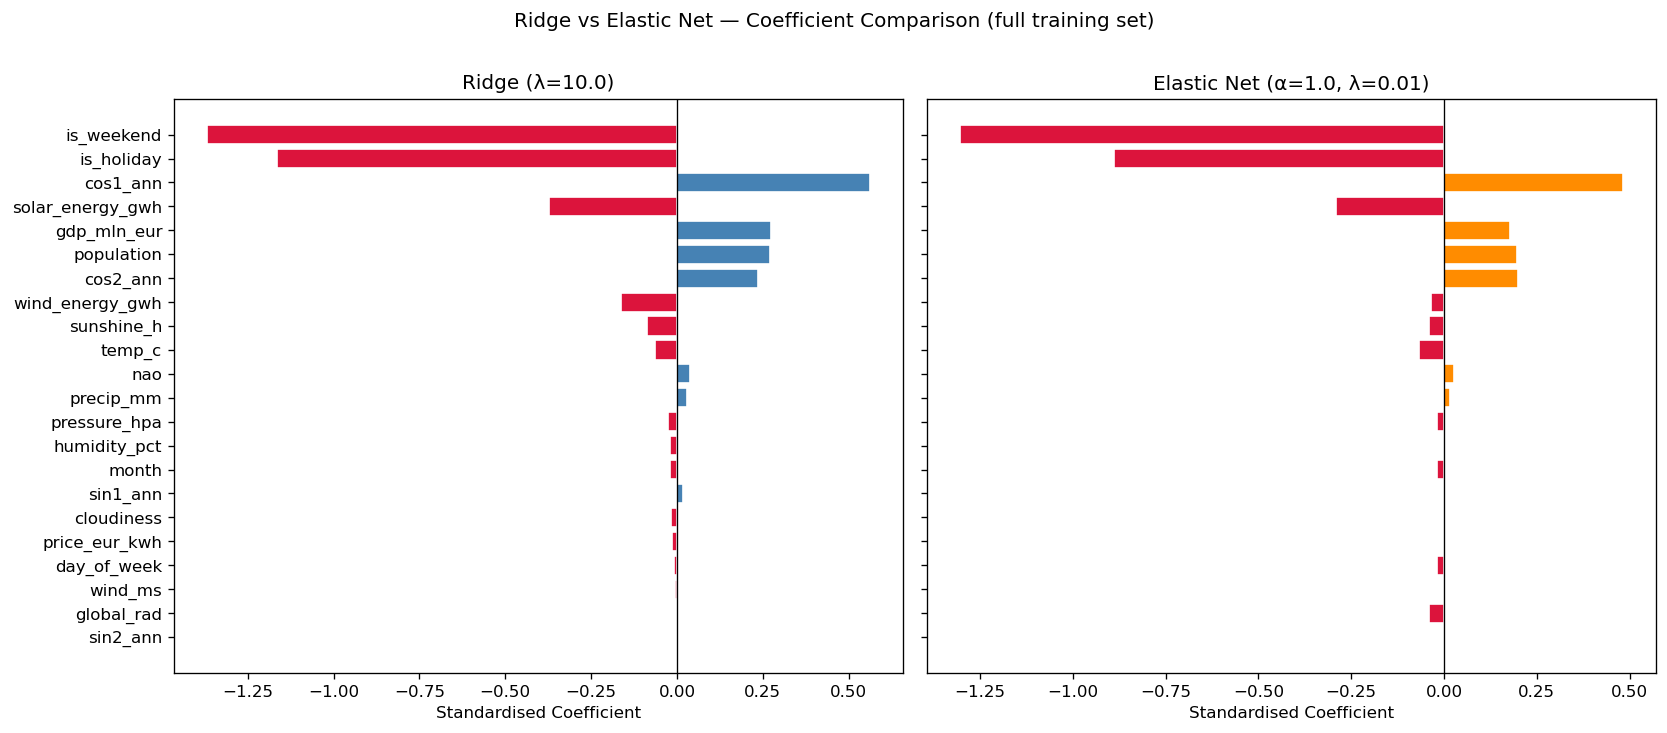

Saved: plots/ridge_vs_elasticnet_coefs.png


In [25]:
# ── Coefficient comparison: Ridge vs Elastic Net ───────────────────────────
# Shows how the two regularisation strategies weight each feature differently.

coef_compare = pd.DataFrame({
    'feature': ALL_FEAT_NAMES,
    'Ridge': ridge_final.coef_,
    'ElasticNet': enet_final.coef_
}).set_index('feature')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, col, color, title in [
    (axes[0], 'Ridge',      'steelblue', f'Ridge (λ={LAMBDA_RIDGE})'),
    (axes[1], 'ElasticNet', 'darkorange', f'Elastic Net (α={L1_RATIO_OPT}, λ={ALPHA_OPT})')
]:
    vals = coef_compare[col].sort_values(key=abs, ascending=True)
    colors_bar = ['crimson' if v < 0 else color for v in vals]
    ax.barh(vals.index, vals.values, color=colors_bar, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(title)
    ax.set_xlabel('Standardised Coefficient')

plt.suptitle('Ridge vs Elastic Net — Coefficient Comparison (full training set)', y=1.01)
plt.tight_layout()
plt.savefig('plots/ridge_vs_elasticnet_coefs.png', bbox_inches='tight')
plt.show()
print('Saved: plots/ridge_vs_elasticnet_coefs.png')

In [26]:
# ── Final output verification ──────────────────────────────────────────────
import os

outputs = [
    'data/strategy_ols_all_params.json',      # Strategy 0 — OLS-All (uses ridge matrices)
    'data/strategy_filtered_train.csv',
    'data/strategy_filtered_val.csv',
    'data/strategy_filtered_test.csv',
    'data/strategy_pca_train.csv',
    'data/strategy_pca_val.csv',
    'data/strategy_pca_test.csv',
    'data/strategy_pca_components.csv',
    'data/strategy_ridge_train.csv',
    'data/strategy_ridge_val.csv',
    'data/strategy_ridge_test.csv',
    'data/strategy_ridge_params.json',
    'data/strategy_elasticnet_train.csv',
    'data/strategy_elasticnet_val.csv',
    'data/strategy_elasticnet_test.csv',
    'data/strategy_elasticnet_params.json',
    'data/predictor_strategies_summary.csv',
]

print('Output files:')
for f in outputs:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) // 1024 if exists else 0
    status = f'✓  {size:>4} KB' if exists else '✗  MISSING'
    print(f'  {status}  {f}')

print()
lasso_label = f'Lasso (l1_ratio={L1_RATIO_OPT})' if L1_RATIO_OPT == 1.0 else f'Elastic Net (α={L1_RATIO_OPT})'
print('Strategy 0 — OLS-All (Unregularised)  →', len(ALL_FEAT_NAMES), 'features (uses ridge matrices)')
print('Strategy 1 — Correlation Filter       →', len(FILTERED_FEATURES), 'features')
print('Strategy 2 — PCA                      →', n_components_95, 'components +', len(CALENDAR), 'calendar')
print('Strategy 3 — Ridge                    →', len(ALL_FEAT_NAMES), 'features, λ =', LAMBDA_RIDGE)
print(f'Strategy 4 — {lasso_label:<30} →', len(enet_selected_final), 'features, α =', L1_RATIO_OPT, 'λ =', ALPHA_OPT)

Output files:
  ✓     0 KB  data/strategy_ols_all_params.json
  ✓  1395 KB  data/strategy_filtered_train.csv
  ✓   295 KB  data/strategy_filtered_val.csv
  ✓   294 KB  data/strategy_filtered_test.csv
  ✓  1147 KB  data/strategy_pca_train.csv
  ✓   242 KB  data/strategy_pca_val.csv
  ✓   240 KB  data/strategy_pca_test.csv
  ✓     0 KB  data/strategy_pca_components.csv
  ✓  1559 KB  data/strategy_ridge_train.csv
  ✓   329 KB  data/strategy_ridge_val.csv
  ✓   328 KB  data/strategy_ridge_test.csv
  ✓     0 KB  data/strategy_ridge_params.json
  ✓  1232 KB  data/strategy_elasticnet_train.csv
  ✓   259 KB  data/strategy_elasticnet_val.csv
  ✓   259 KB  data/strategy_elasticnet_test.csv
  ✓     0 KB  data/strategy_elasticnet_params.json
  ✓     0 KB  data/predictor_strategies_summary.csv

Strategy 0 — OLS-All (Unregularised)  → 22 features (uses ridge matrices)
Strategy 1 — Correlation Filter       → 20 features
Strategy 2 — PCA                      → 9 components + 8 calendar
Strategy 3 — Ri